# Agentic rag test

In [2]:
# 模型初始化
from langchain_ollama import ChatOllama, OllamaEmbeddings

from test.agent_with_rag.tools.visualization import python_repl

qwen = ChatOllama(model = "qwen2.5:7b")
embedding_model = OllamaEmbeddings(
    model="nomic-embed-text",
)


In [3]:

from langchain_chroma import Chroma

vectorstore = Chroma(
    collection_name="example_collection",
    embedding_function=embedding_model,
    persist_directory="./chroma_langchain_db"
)


# 加载excel文件太慢了
```python
from langchain_community.document_loaders import CSVLoader
from langchain_community.document_loaders import UnstructuredExcelLoader
def load_documents(file_path: str):
    if file_path.endswith('.csv'):
        loader = CSVLoader(file_path)
    if file_path.endswith('.xlsx'):
        loader = UnstructuredExcelLoader(file_path)
    return loader.load()

```

In [4]:
import pandas as pd
from langchain_community.document_loaders import CSVLoader

def load_documents(file_path: str):
    if file_path.endswith('.csv'):
        loader = CSVLoader(file_path)
    elif file_path.endswith('.xlsx'):
        # 转换Excel为临时CSV
        df = pd.read_excel(file_path)
        temp_csv_path = "temp.csv"
        df.to_csv(temp_csv_path, index=False)
        loader = CSVLoader(temp_csv_path)
    return loader.load()

In [5]:

docs = load_documents("/home/lreuxcu/AetherCell/src/resource/USA GDP Growth 1961-2021.xlsx")

In [6]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=100, chunk_overlap=50
)
doc_splits = text_splitter.split_documents(docs)

In [7]:
_ = vectorstore.add_documents(documents=doc_splits)
retriever = vectorstore.as_retriever()

In [13]:
from langchain.tools.retriever import create_retriever_tool
from tools.loader import readfile
retriever_tool = create_retriever_tool(
    retriever,
    "retrieve",
    "搜索并返回与用户提问相关文件的信息",
)
retriever_tool = [retriever_tool]

In [11]:

from typing import Annotated, Sequence
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage

from langgraph.graph.message import add_messages


class AgentState(TypedDict):
    # The add_messages function defines how an update should be processed
    # Default is to replace. add_messages says "append"
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [22]:


from test.agent_with_rag.tools.loader import readfile
from typing import Annotated, Literal, Sequence
from typing_extensions import TypedDict

from langchain import hub
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate

from pydantic import BaseModel, Field


from langgraph.prebuilt import tools_condition

### Edges


def grade_documents(state) -> Literal["generate", "rewrite"]:
    """
    确定检索到的文档是否与问题相关。

    Args：
    state (messages)：当前状态

    Returns：
    str：文档是否相关的决定
    """
    print("---CHECK RELEVANCE---")

    # Data model
    class grade(BaseModel):
        """Binary score for relevance check."""

        binary_score: str = Field(description="Relevance score 'yes' or 'no'")

    # LLM
    model = qwen

    # LLM with tool and validation
    llm_with_tool = model.with_structured_output(grade)

    # Prompt
    prompt = PromptTemplate(
    template="""您是一名评分员，正在评估检索到的文档与用户问题的相关性。\n
    这是检索到的文档：\n\n {context} \n\n
    这是用户问题：{question} \n
    如果文档包含与用户问题相关的关键字或语义含义，则将其评为相关。\n
    给出二进制分数“是”或“否”以指示文档是否与问题相关。""",
        input_variables=["context", "question"],
    )

    # Chain
    chain = prompt | llm_with_tool

    messages = state["messages"]
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate"

    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        print(score)
        return "rewrite"


### Nodes


def agent(state):
    """
    Invokes the agent model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply end.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with the agent response appended to messages
    """
    messages = state["messages"]

    model = llm_with_tools
    response = llm_with_tools.invoke(messages)
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}


def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    messages = state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f""" \n
    Look at the input and try to reason about the underlying semantic intent / meaning. \n
    Here is the initial question:
    \n ------- \n
    {question}
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    # Grader
    model = qwen
    response = model.invoke(msg)
    return {"messages": [response]}


def generate(state):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated state with re-phrased question
    """
    print("---GENERATE---")
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    # Prompt
    prompt = hub.pull("rlm/rag-prompt")

    # LLM
    llm = qwen

    # Post-processing
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    # Chain
    rag_chain = prompt | llm | StrOutputParser()

    # Run
    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}


print("*" * 20 + "Prompt[rlm/rag-prompt]" + "*" * 20)
prompt = hub.pull("rlm/rag-prompt").pretty_print()  # Show what the prompt looks like
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode

# Define a new graph
workflow = StateGraph(AgentState)

# Define the nodes we will cycle between
workflow.add_node("agent", agent)  # agent
retrieve = ToolNode(retriever_tool)
tool_node = ToolNode(tools=tools)
workflow.add_node("retrieve", retrieve)  # retrieval
workflow.add_node("rewrite", rewrite)  # Re-writing the question
workflow.add_node("tools", tool_node)
workflow.add_node(
    "generate", generate
)  # Generating a response after we know the documents are relevant
# Call agent node to decide to retrieve or not

workflow.add_edge(START, "agent")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "agent",
    # Assess agent decision
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "retrieve": "retrieve",
        "tools": "tools",
        END: END,
    },
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# Compile
graph = workflow.compile()


********************Prompt[rlm/rag-prompt]********************


/home/lreuxcu/anaconda3/envs/DL/lib/python3.12/site-packages/langsmith/client.py:241: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


================================ Human Message =================================

You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: {question} 
Context: {context} 
Answer:


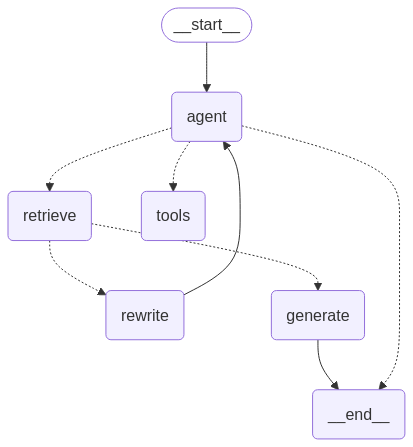

In [24]:

from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [17]:
import pprint

inputs = {
    "messages": [
        ("user", "2021的GDP是多少"),
    ]
}
for output in graph.stream(inputs):
    for key, value in output.items():
        pprint.pprint(f"Output from node '{key}':")
        pprint.pprint("---")
        pprint.pprint(value, indent=2, width=80, depth=None)
    pprint.pprint("\n---\n")

"Output from node 'agent':"
'---'
{ 'messages': [ AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen2.5:7b', 'created_at': '2025-03-22T07:30:27.053932245Z', 'done': True, 'done_reason': 'stop', 'total_duration': 17750710295, 'load_duration': 14808946277, 'prompt_eval_count': 170, 'prompt_eval_duration': 1144000000, 'eval_count': 51, 'eval_duration': 1260000000, 'message': Message(role='assistant', content='', images=None, tool_calls=None)}, id='run-27d1dfce-d402-4c2e-ade4-64596d0f4768-0', tool_calls=[{'name': 'retrieve', 'args': {'query': '2021年GDP'}, 'id': '1599ad91-8a26-400d-afba-c6756a1ae024', 'type': 'tool_call'}], usage_metadata={'input_tokens': 170, 'output_tokens': 51, 'total_tokens': 221})]}
'\n---\n'
---CHECK RELEVANCE---
---DECISION: DOCS RELEVANT---
"Output from node 'retrieve':"
'---'
{ 'messages': [ ToolMessage(content='Year: 2021\nGDP: $22,996.10B\nGDP per Capita: 69288\nGrowth: 0.0567\n\nYear: 2021\nGDP: $22,996.10B\nGDP per Capita: 69288\nGrow

/home/lreuxcu/anaconda3/envs/DL/lib/python3.12/site-packages/langsmith/client.py:241: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


"Output from node 'generate':"
'---'
{'messages': ['2021年的GDP为22,996.10亿美元。']}
'\n---\n'
